# Sample Selection and Normality Model Building

This notebook first loads the dataset obtained after removing highly correlated features with the KPI. Next, the methodology uses various steps to extract samples that describe normal network behavior. This sequence of steps also allows us to identify performance outliers and anomalies. Then, the routine builds an XGBoost regression model that characterizes normal network behavior. In this case, we need the ``xgboost`` library to construct the regression model.

## Import Libraries

In [3]:
import pandas as pd
import numpy as np

# Ploting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn libraries
from sklearn import model_selection 
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest

from sklearn.metrics import jaccard_score
from sklearn.metrics import recall_score, precision_score
from sklearn.metrics import make_scorer, f1_score

from sklearn.neighbors import LocalOutlierFactor

import imblearn
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

import statsmodels.api as sm
import xgboost as xgb
import shap

import warnings
warnings.filterwarnings('ignore')

## Loading the Dataset

This stage loads the dataset obtained after removing the features that are highly correlated to the KPI.

In [5]:
print('-----------------------------------------')
print('LOADING DATASET A FILE DOWNLOAD DATASET')
data_file = 'data/Op1_CapDL_NoSteps_wo_correlated_features.csv'
# data_file = 'data/FileDL_Nokia_wo_correlated_features.csv'
# data_file = 'data/LivePageDL_Nokia_wo_correlated_features.csv'
data = pd.read_csv(data_file, sep=",", decimal='.', low_memory = False)
data = data.drop(columns=['Unnamed: 0'])
print('Data Size:(%d, %d)'%(data.shape[0], data.shape[1]))
print('-----------------------------------------')
target_kpi = 'transfer.datarate'
# target_kpi = 'test.throughput.kbit.s'
kpi_aux    = data[target_kpi]
data.describe()

-----------------------------------------
LOADING DATASET A FILE DOWNLOAD DATASET
Data Size:(1001, 120)
-----------------------------------------


,resets.sent.a2b,ack.pkts.sent.a2b,pure.acks.sent.b2a,sack.pkts.sent.b2a,dsack.pkts.sent.a2b,rexmt.data.bytes.a2b,rexmt.data.bytes.b2a,outoforder.pkts.b2a,max.segm.size.b2a,min.segm.size.a2b,...,abs.segmentsizes.25.,abs.segmentsizes.50.,abs.segmentsizes.max,abs.packetlost.sum,abs.instanttp.min,abs.burst.sum,abs.rtoevents.sum,abs.theoricalmaxtp.avg,abs.theoricalmaxtp.max,transfer.datarate
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1.001000e+03,1001.000000,1001.000000,1001.000000,...,1001.000000,1001.000000,1.001000e+03,1001.000000,1001.000000,1001.000000,1001.000000,1.001000e+03,1.001000e+03,1.001000e+03
mean,128.041958,23504.771229,19.445554,0.000999,645.926074,2.017982,2.334520e+06,1028.684316,62737.201798,231.181818,...,2597.134615,6170.843157,1.137196e+05,203.033966,0.000159,63.993007,236.949051,6.736559e+09,3.329800e+13,3.934347e+05
std,95.049736,11232.441681,35.021355,0.031607,3311.848603,46.315242,7.746871e+06,4453.186531,8786.050549,9.141931,...,457.538529,1642.232733,6.787134e+05,577.700565,0.000095,159.287303,1485.634821,1.424162e+10,2.990747e+13,1.984722e+05
min,0.000000,1299.000000,5.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,5308.000000,64.000000,...,660.000000,1327.000000,5.538000e+03,0.000000,0.000080,0.000000,0.000000,2.317959e+00,9.010940e+00,2.408967e+03
25%,62.000000,18357.000000,6.000000,0.000000,0.000000,0.000000,0.000000e+00,32.000000,65236.000000,232.000000,...,2776.000000,5552.000000,6.523600e+04,0.000000,0.000080,0.000000,0.000000,9.986515e+02,6.019258e+04,2.530839e+05
50%,117.000000,23260.000000,9.000000,0.000000,23.000000,0.000000,1.081380e+05,75.000000,65236.000000,232.000000,...,2776.000000,6940.000000,6.523600e+04,37.000000,0.000160,13.000000,3.000000,2.691650e+09,3.004338e+13,3.813481e+05
75%,176.000000,27219.000000,17.000000,0.000000,185.000000,0.000000,1.393763e+06,322.000000,65236.000000,232.000000,...,2776.000000,6940.000000,6.523600e+04,173.000000,0.000240,53.000000,26.000000,7.241105e+09,5.818665e+13,5.196789e+05
max,748.000000,105106.000000,521.000000,1.000000,31047.000000,1397.000000,8.789408e+07,41515.000000,65236.000000,232.000000,...,4164.000000,9716.000000,1.389992e+07,9177.000000,0.000400,1956.000000,15336.000000,1.970290e+11,1.836066e+14,1.275028e+06


## Performance Outlier and Anomaly Detection

### Outliers in Features

In [8]:
data = data.loc[:,data.columns != target_kpi]
data[target_kpi] = np.log10(kpi_aux)

scaler    = StandardScaler()
detector0 = OneClassSVM(gamma='auto', kernel='poly', degree=3).fit(scaler.fit_transform(data))
anomaly0  = detector0.predict(scaler.fit_transform(data))
if (np.sum(anomaly0 == 1) > np.sum(anomaly0 == -1)):
    anomaly0 = -anomaly0
outliers_features = (anomaly0 == 1)
print('Outlier Rate in Features: %.4f'%(np.mean(outliers_features)))

Outlier Rate in Features: 0.4106


### Outliers in the KPI

In [10]:
data_nrm = data[target_kpi].to_numpy() / np.std(data[target_kpi])
Q3 = np.quantile(data_nrm, 0.75) - np.mean(data_nrm)
if (Q3 != 0):
    med = np.median(data[target_kpi])
    MAD = (1/Q3) * np.median(np.absolute(data[target_kpi] - med))
    outliers_kpi = (data[target_kpi] > med + 3.0*MAD)|(data[target_kpi] < med - 3.0*MAD)
print('Outlier Rate in KPI: %.4f'%(np.mean(outliers_kpi)))

atypical = pd.DataFrame(columns=['outliers'])
atypical['outliers'] = outliers_kpi
# atypical.to_csv('data/FileDL_outliers.csv')
# atypical.to_csv('data/LivePageDL_outliers.csv')

Outlier Rate in KPI: 0.0420


#### Comparison with other outlier detectors using the same outlier rate

In [12]:
print('-------------------------------')
print('ISOLATION FOREST')
if_detector = IsolationForest(contamination = np.mean(outliers_kpi), 
                              random_state=47)
param_grid  = {'n_estimators': list(range(100, 501, 40)), 
               'bootstrap': [True, False]}
f1sc = make_scorer(f1_score, average='micro')
grid_if_detector = model_selection.GridSearchCV(if_detector, 
                                                param_grid,
                                                scoring=f1sc, 
                                                cv=10, 
                                                return_train_score=True)

grid_if_detector.fit(data.iloc[:, data.columns == target_kpi], outliers_kpi)
anomaly1 = grid_if_detector.best_estimator_.predict(data.iloc[:, data.columns == target_kpi])
if (np.sum(anomaly1 == 1) > np.sum(anomaly1 == -1)):
    anomaly1 = -anomaly1
outliers_kpi_if = (anomaly1 == 1)
print('Optimization Finished')
print('-------------------------------')
print('')

print('-------------------------------')
print('LOOCAL OUTLIER FACTOR')
lof_detector = LocalOutlierFactor(contamination = np.mean(outliers_kpi))
param_grid  = {'n_neighbors': list(range(20, 420, 20))}
grid_lof_detector = model_selection.GridSearchCV(lof_detector, 
                                                 param_grid,
                                                 scoring=f1sc, 
                                                 cv=10, 
                                                 return_train_score=True)

grid_lof_detector.fit(data.iloc[:, data.columns == target_kpi], outliers_kpi)
anomaly2 = grid_lof_detector.best_estimator_.fit_predict(data.iloc[:, data.columns == target_kpi])
outliers_kpi_lof = (anomaly2 == -1)
print('Optimization Finished')
print('-------------------------------')
print('')

print('-------------------------------')
print('One Class SVM')
scaler    = StandardScaler()
ocsvm_detector = OneClassSVM(max_iter=1000)
param_grid  = {'kernel':['poly'],
               'gamma': [1, 2, 5, 10],
               'degree': [3, 5, 7]}
grid_ocsvm_detector = model_selection.GridSearchCV(ocsvm_detector, 
                                                   param_grid,
                                                   scoring=f1sc, 
                                                   cv=10, 
                                                   return_train_score=True)

data_in = scaler.fit_transform(data.iloc[:, data.columns == target_kpi]).reshape(-1,1)
grid_ocsvm_detector.fit(data_in, outliers_kpi.to_numpy().reshape(-1,1))
anomaly3 = grid_ocsvm_detector.best_estimator_.predict(data_in)
outliers_kpi_ocsvm = (anomaly3 == 1)
print('Optimization Finished')
print('-------------------------------')
print('')

-------------------------------
ISOLATION FOREST
Optimization Finished
-------------------------------

-------------------------------
LOOCAL OUTLIER FACTOR
Optimization Finished
-------------------------------

-------------------------------
One Class SVM
Optimization Finished
-------------------------------



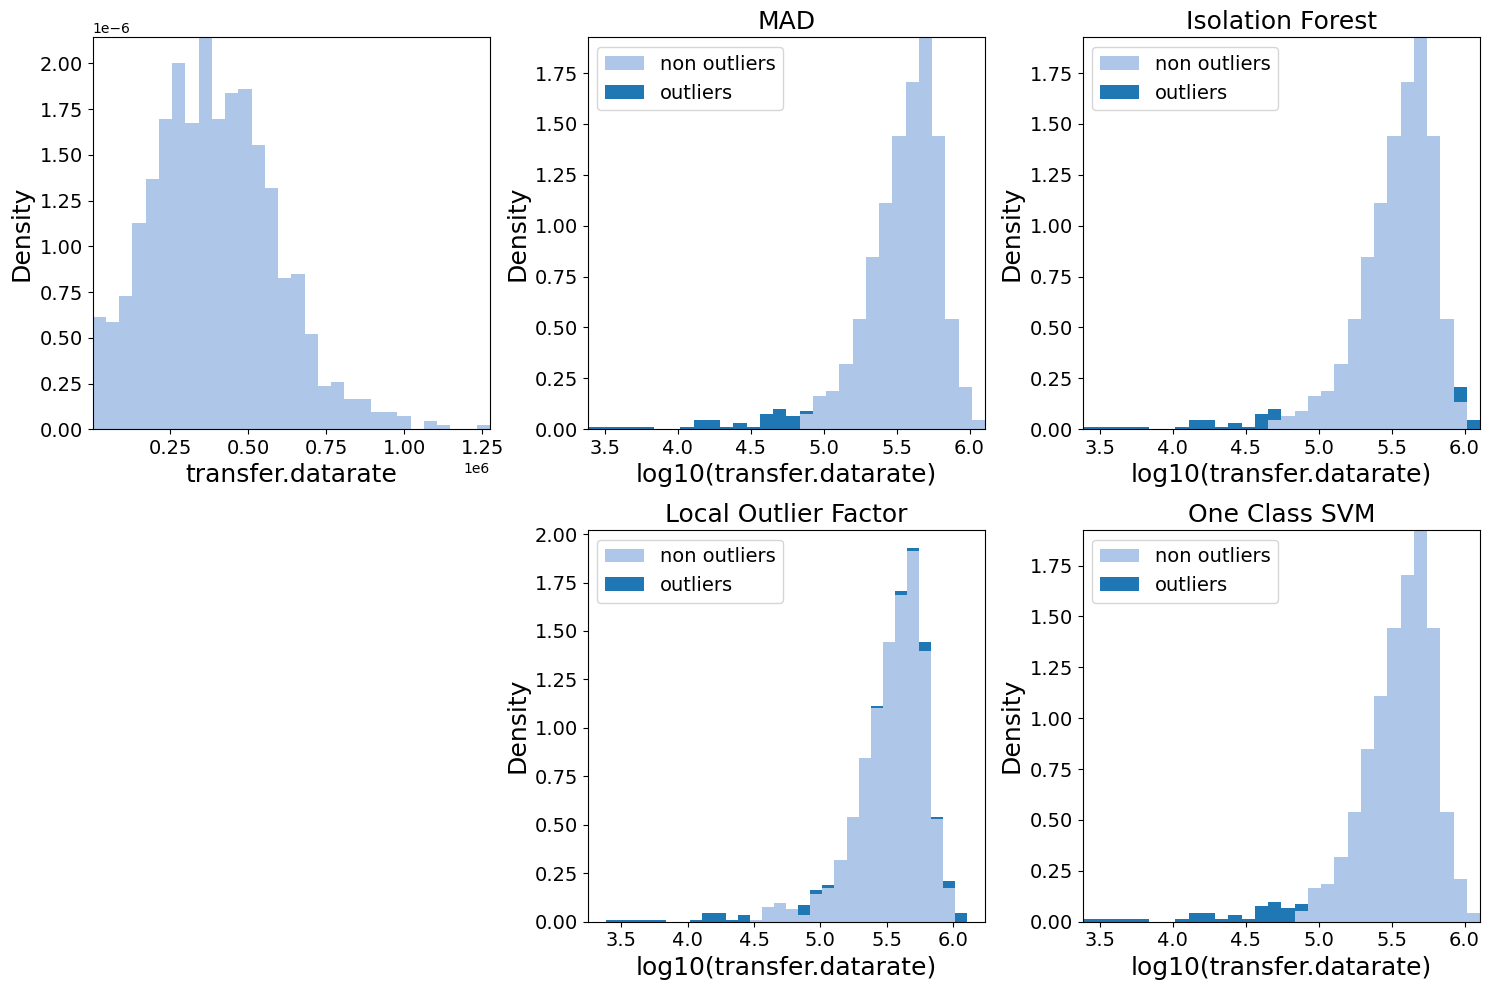

,method,Sensitivity,Specificity,F1-score,Precision,Jaccard
0,Isolation Forest,0.738095,0.988530,0.738095,0.738095,0.584906
1,Local Outlier Factor,0.428571,0.974974,0.428571,0.428571,0.272727
2,One Class SVM,1.000000,0.997914,0.976744,0.954545,0.954545


In [13]:
fig = plt.figure(figsize=(15,10), tight_layout=True)
ax = fig.add_subplot(2,3,1)
ax.hist(kpi_aux, 
        bins=30, 
        density = True,
        color=sns.color_palette("tab20")[1],
        stacked=True,
        )
plt.tick_params(axis='both', labelsize=14)
plt.xlabel('transfer.datarate', fontsize=18)
plt.ylabel('Density', fontsize=18)
plt.autoscale(axis='both', tight=True)

anomaly_classes = np.unique(outliers_kpi)
ax = fig.add_subplot(2,3,2)
ax.hist([data[target_kpi].to_numpy()[outliers_kpi == i] for i in anomaly_classes], 
        bins=30, 
        density = True,
        color=[sns.color_palette("tab20")[1],sns.color_palette("tab20")[0]],
        stacked=True,
        label = ['non outliers', 
                 'outliers'])
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=14)
plt.xlabel('log10(transfer.datarate)', fontsize=18)
plt.ylabel('Density', fontsize=18)
plt.title('MAD', fontsize=18)
plt.autoscale(axis='both', tight=True)


anomaly_classes = np.unique(outliers_kpi_if)
ax = fig.add_subplot(2,3,3)
ax.hist([data[target_kpi].to_numpy()[outliers_kpi_if == i] for i in anomaly_classes], 
        bins=30, 
        density = True,
        color=[sns.color_palette("tab20")[1],sns.color_palette("tab20")[0]],
        stacked=True,
        label = ['non outliers', 
                 'outliers'])
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=14)
plt.xlabel('log10(transfer.datarate)', fontsize=18)
plt.ylabel('Density', fontsize=18)
plt.title('Isolation Forest', fontsize=18)
plt.autoscale(axis='both', tight=True)


anomaly_classes = np.unique(outliers_kpi_lof)
ax = fig.add_subplot(2,3,5)
ax.hist([data[target_kpi].to_numpy()[outliers_kpi_lof == i] for i in anomaly_classes], 
        bins=30, 
        density = True,
        color=[sns.color_palette("tab20")[1],sns.color_palette("tab20")[0]],
        stacked=True,
        label = ['non outliers', 
                 'outliers'])
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=14)
plt.xlabel('log10(transfer.datarate)', fontsize=18)
plt.ylabel('Density', fontsize=18)
plt.title('Local Outlier Factor', fontsize=18)

anomaly_classes = np.unique(outliers_kpi_ocsvm)
ax = fig.add_subplot(2,3,6)
ax.hist([data[target_kpi].to_numpy()[outliers_kpi_ocsvm == i] for i in anomaly_classes], 
        bins=30, 
        density = True,
        color=[sns.color_palette("tab20")[1],sns.color_palette("tab20")[0]],
        stacked=True,
        label = ['non outliers', 
                 'outliers'])
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=14)
plt.xlabel('log10(transfer.datarate)', fontsize=18)
plt.ylabel('Density', fontsize=18)
plt.title('One Class SVM', fontsize=18)
plt.autoscale(axis='both', tight=True)
plt.show()

sens_if = recall_score(outliers_kpi, outliers_kpi_if)
spec_if = recall_score(outliers_kpi, outliers_kpi_if, pos_label=0)
f1sr_if = f1_score(outliers_kpi, outliers_kpi_if)
prec_if = precision_score(outliers_kpi, outliers_kpi_if)
jacc_if = jaccard_score(outliers_kpi, outliers_kpi_if)

sens_lof = recall_score(outliers_kpi, outliers_kpi_lof)
spec_lof = recall_score(outliers_kpi, outliers_kpi_lof, pos_label=0)
f1sr_lof = f1_score(outliers_kpi, outliers_kpi_lof)
prec_lof = precision_score(outliers_kpi, outliers_kpi_lof)
jacc_lof = jaccard_score(outliers_kpi, outliers_kpi_lof)

sens_ocsvm = recall_score(outliers_kpi, outliers_kpi_ocsvm)
spec_ocsvm = recall_score(outliers_kpi, outliers_kpi_ocsvm, pos_label=0)
f1sr_ocsvm = f1_score(outliers_kpi, outliers_kpi_ocsvm)
prec_ocsvm = precision_score(outliers_kpi, outliers_kpi_ocsvm)
jacc_ocsvm = jaccard_score(outliers_kpi, outliers_kpi_ocsvm)


comparison = pd.DataFrame(columns=['method','Sensitivity','Specificity','F1-score','Precision','Jaccard'])
comparison['method']=['Isolation Forest', 'Local Outlier Factor', 'One Class SVM']
comparison['Sensitivity'] = [sens_if, sens_lof, sens_ocsvm]
comparison['Specificity'] = [spec_if, spec_lof, spec_ocsvm]
comparison['F1-score'] = [f1sr_if, f1sr_lof, f1sr_ocsvm]
comparison['Precision'] = [prec_if, prec_lof, prec_ocsvm]
comparison['Jaccard'] = [jacc_if, jacc_lof, jacc_ocsvm]

comparison

#### Comparison with other outlier detectors using the different outlier rates

In [15]:
print('-------------------------------')
print('ISOLATION FOREST')
if_detector = IsolationForest(contamination = np.mean(outliers_kpi), 
                              random_state=47)
param_grid  = {'n_estimators': list(range(100, 501, 40)), 
               'bootstrap': [True, False],
               'contamination': [0.01, 0.02, 0.05, 0.1]}
f1sc = make_scorer(f1_score, average='micro')
grid_if_detector = model_selection.GridSearchCV(if_detector, 
                                                param_grid,
                                                scoring=f1sc, 
                                                cv=10, 
                                                return_train_score=True)

grid_if_detector.fit(data.iloc[:, data.columns == target_kpi], outliers_kpi)
anomaly1 = grid_if_detector.best_estimator_.predict(data.iloc[:, data.columns == target_kpi])
if (np.sum(anomaly1 == 1) > np.sum(anomaly1 == -1)):
    anomaly1 = -anomaly1
outliers_kpi_if = (anomaly1 == 1)
print('Optimization Finished')
print('-------------------------------')
print('')

print('-------------------------------')
print('LOOCAL OUTLIER FACTOR')
lof_detector = LocalOutlierFactor(contamination = np.mean(outliers_kpi))
param_grid  = {'n_neighbors': list(range(20, 420, 20)),
               'contamination': [0.01, 0.02, 0.05, 0.1]}
grid_lof_detector = model_selection.GridSearchCV(lof_detector, 
                                                 param_grid,
                                                 scoring=f1sc, 
                                                 cv=10, 
                                                 return_train_score=True)

grid_lof_detector.fit(data.iloc[:, data.columns == target_kpi], outliers_kpi)
anomaly2 = grid_lof_detector.best_estimator_.fit_predict(data.iloc[:, data.columns == target_kpi])
outliers_kpi_lof = (anomaly2 == -1)
print('Optimization Finished')
print('-------------------------------')
print('')

-------------------------------
ISOLATION FOREST
Optimization Finished
-------------------------------

-------------------------------
LOOCAL OUTLIER FACTOR
Optimization Finished
-------------------------------



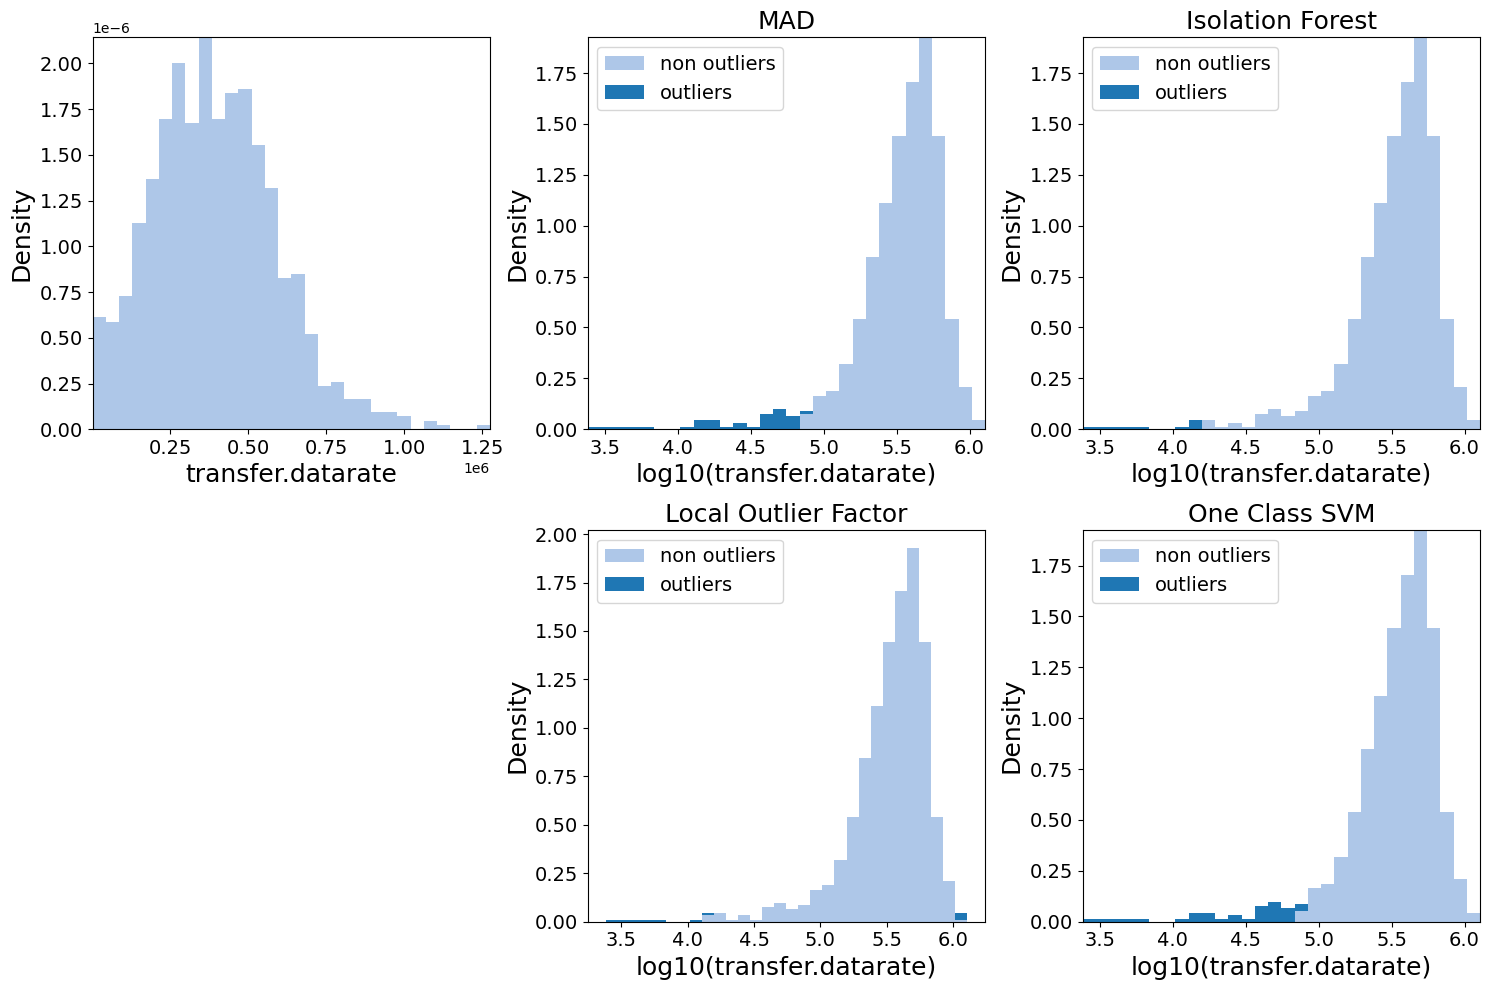

,method,Sensitivity,Specificity,F1-score,Precision,Jaccard,Rate
0,Isolation Forest,0.238095,1.000000,0.384615,1.000000,0.238095,0.009990
1,Local Outlier Factor,0.166667,0.996872,0.269231,0.700000,0.155556,0.009990
2,One Class SVM,1.000000,0.997914,0.976744,0.954545,0.954545,0.043956


In [16]:
fig = plt.figure(figsize=(15,10), tight_layout=True)
ax = fig.add_subplot(2,3,1)
ax.hist(kpi_aux, 
        bins=30, 
        density = True,
        color=sns.color_palette("tab20")[1],
        stacked=True,
        )
plt.tick_params(axis='both', labelsize=14)
plt.xlabel('transfer.datarate', fontsize=18)
plt.ylabel('Density', fontsize=18)
plt.autoscale(axis='both', tight=True)

anomaly_classes = np.unique(outliers_kpi)
ax = fig.add_subplot(2,3,2)
ax.hist([data[target_kpi].to_numpy()[outliers_kpi == i] for i in anomaly_classes], 
        bins=30, 
        density = True,
        color=[sns.color_palette("tab20")[1],sns.color_palette("tab20")[0]],
        stacked=True,
        label = ['non outliers', 
                 'outliers'])
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=14)
plt.xlabel('log10(transfer.datarate)', fontsize=18)
plt.ylabel('Density', fontsize=18)
plt.title('MAD', fontsize=18)
plt.autoscale(axis='both', tight=True)


anomaly_classes = np.unique(outliers_kpi_if)
ax = fig.add_subplot(2,3,3)
ax.hist([data[target_kpi].to_numpy()[outliers_kpi_if == i] for i in anomaly_classes], 
        bins=30, 
        density = True,
        color=[sns.color_palette("tab20")[1],sns.color_palette("tab20")[0]],
        stacked=True,
        label = ['non outliers', 
                 'outliers'])
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=14)
plt.xlabel('log10(transfer.datarate)', fontsize=18)
plt.ylabel('Density', fontsize=18)
plt.title('Isolation Forest', fontsize=18)
plt.autoscale(axis='both', tight=True)


anomaly_classes = np.unique(outliers_kpi_lof)
ax = fig.add_subplot(2,3,5)
ax.hist([data[target_kpi].to_numpy()[outliers_kpi_lof == i] for i in anomaly_classes], 
        bins=30, 
        density = True,
        color=[sns.color_palette("tab20")[1],sns.color_palette("tab20")[0]],
        stacked=True,
        label = ['non outliers', 
                 'outliers'])
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=14)
plt.xlabel('log10(transfer.datarate)', fontsize=18)
plt.ylabel('Density', fontsize=18)
plt.title('Local Outlier Factor', fontsize=18)

anomaly_classes = np.unique(outliers_kpi_ocsvm)
ax = fig.add_subplot(2,3,6)
ax.hist([data[target_kpi].to_numpy()[outliers_kpi_ocsvm == i] for i in anomaly_classes], 
        bins=30, 
        density = True,
        color=[sns.color_palette("tab20")[1],sns.color_palette("tab20")[0]],
        stacked=True,
        label = ['non outliers', 
                 'outliers'])
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=14)
plt.xlabel('log10(transfer.datarate)', fontsize=18)
plt.ylabel('Density', fontsize=18)
plt.title('One Class SVM', fontsize=18)
plt.autoscale(axis='both', tight=True)
plt.show()

sens_if = recall_score(outliers_kpi, outliers_kpi_if)
spec_if = recall_score(outliers_kpi, outliers_kpi_if, pos_label=0)
f1sr_if = f1_score(outliers_kpi, outliers_kpi_if)
prec_if = precision_score(outliers_kpi, outliers_kpi_if)
jacc_if = jaccard_score(outliers_kpi, outliers_kpi_if)
rate_if = np.mean(outliers_kpi_if)

sens_lof = recall_score(outliers_kpi, outliers_kpi_lof)
spec_lof = recall_score(outliers_kpi, outliers_kpi_lof, pos_label=0)
f1sr_lof = f1_score(outliers_kpi, outliers_kpi_lof)
prec_lof = precision_score(outliers_kpi, outliers_kpi_lof)
jacc_lof = jaccard_score(outliers_kpi, outliers_kpi_lof)
rate_lof = np.mean(outliers_kpi_lof)

sens_ocsvm = recall_score(outliers_kpi, outliers_kpi_ocsvm)
spec_ocsvm = recall_score(outliers_kpi, outliers_kpi_ocsvm, pos_label=0)
f1sr_ocsvm = f1_score(outliers_kpi, outliers_kpi_ocsvm)
prec_ocsvm = precision_score(outliers_kpi, outliers_kpi_ocsvm)
jacc_ocsvm = jaccard_score(outliers_kpi, outliers_kpi_ocsvm)
rate_ocsvm = np.mean(outliers_kpi_ocsvm)

comparison = pd.DataFrame(columns=['method','Sensitivity','Specificity','F1-score','Precision','Jaccard','Rate'])
comparison['method']=['Isolation Forest', 'Local Outlier Factor', 'One Class SVM']
comparison['Sensitivity'] = [sens_if, sens_lof, sens_ocsvm]
comparison['Specificity'] = [spec_if, spec_lof, spec_ocsvm]
comparison['F1-score'] = [f1sr_if, f1sr_lof, f1sr_ocsvm]
comparison['Precision'] = [prec_if, prec_lof, prec_ocsvm]
comparison['Jaccard'] = [jacc_if, jacc_lof, jacc_ocsvm]
comparison['Rate'] = [rate_if, rate_lof, rate_ocsvm]

comparison

## Training the Normality Model

In [18]:
data_normality  = data.copy()
data_normality  = data[~(outliers_features|outliers_kpi)]
data_normality[target_kpi] = kpi_aux[~(outliers_features|outliers_kpi)].to_numpy().reshape(-1, 1)

train_cols = data_normality.columns[data_normality.columns != target_kpi]
X_train    = data_normality.loc[:, train_cols]
y_train    = data_normality[target_kpi].to_numpy().reshape(-1, 1) 

model_normality = xgb.XGBRegressor()
model_normality.fit(X_train, y_train)
y_predicted     = model_normality.predict(data[train_cols])

# Linear model on training data
data[target_kpi]      = kpi_aux
y_train_linear_model1 = sm.add_constant(data[target_kpi][~(outliers_features|outliers_kpi)])
linear_model1         = sm.OLS(y_predicted[~(outliers_features|outliers_kpi)], 
                               y_train_linear_model1).fit()
print(linear_model1.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.244e+10
Date:                Wed, 15 Jan 2025   Prob (F-statistic):               0.00
Time:                        09:28:06   Log-Likelihood:                -2570.6
No. Observations:                 584   AIC:                             5145.
Df Residuals:                     582   BIC:                             5154.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 1.9826      2.38

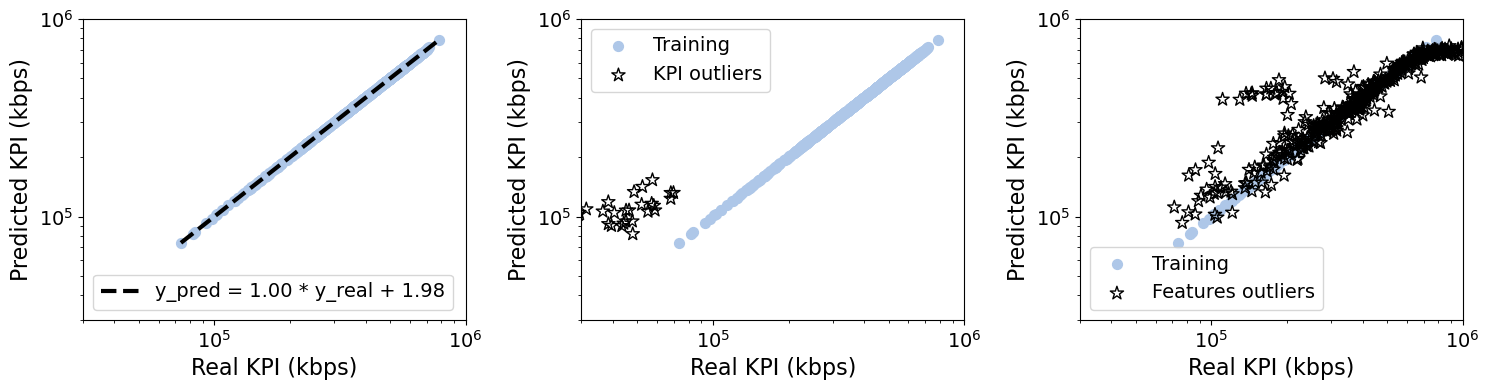

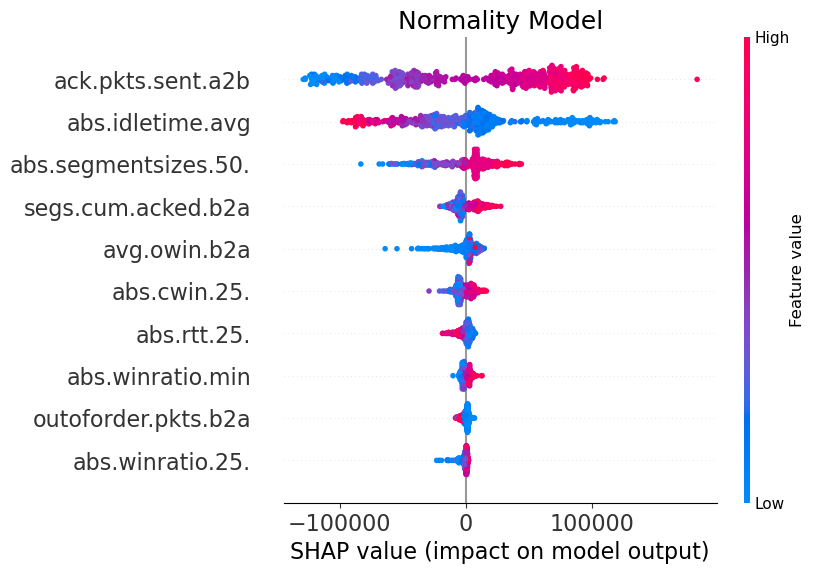

In [19]:
fig = plt.figure(figsize=(15,4))
ax  = fig.add_subplot(1,3,1)
plt.scatter(data[target_kpi][~(outliers_features|outliers_kpi)], 
            y_predicted[~(outliers_features|outliers_kpi)], 
            color=sns.color_palette("tab20")[1], 
            s=50, 
            marker = 'o')
plt.plot([np.min(y_train), np.max(y_train)], 
            [(linear_model1.params[1] * np.min(y_train) + linear_model1.params[0]), (linear_model1.params[1] * np.max(y_train) + linear_model1.params[0])],
            '--',
            color = 'k',
            linewidth=3,
            label = 'y_pred = %.2f * y_real + %.2f'%(linear_model1.params[1], linear_model1.params[0]))
plt.xscale('log')
plt.yscale('log')
plt.xlim([30000, 1000000])
plt.ylim([30000, 1000000])
plt.tick_params(axis='both', labelsize=14)
plt.xlabel('Real KPI (kbps)', fontsize=16)
plt.ylabel('Predicted KPI (kbps)', fontsize=16)
plt.legend(fontsize=14)

ax  = fig.add_subplot(1,3,2)
plt.scatter(data[target_kpi][~(outliers_features|outliers_kpi)], 
            y_predicted[~(outliers_features|outliers_kpi)], 
            color=sns.color_palette("tab20")[1], 
            s=50, 
            marker = 'o',
            label = 'Training')
plt.scatter(data[target_kpi][outliers_kpi], 
            y_predicted[outliers_kpi], 
            s=100, 
            marker = '*', 
            color= 'k', 
            label='KPI outliers', 
            facecolors='none')
plt.xscale('log')
plt.yscale('log')
plt.xlim([30000, 1000000])
plt.ylim([30000, 1000000])
plt.tick_params(axis='both', labelsize=14)
plt.xlabel('Real KPI (kbps)', fontsize=16)
plt.ylabel('Predicted KPI (kbps)', fontsize=16)
plt.legend(fontsize=14)

ax  = fig.add_subplot(1,3,3)
plt.scatter(data[target_kpi][~(outliers_features|outliers_kpi)], 
            y_predicted[~(outliers_features|outliers_kpi)], 
            color=sns.color_palette("tab20")[1], 
            s=50, 
            marker = 'o',
            label = 'Training')
plt.scatter(data[target_kpi][outliers_features&(~outliers_kpi)], 
            y_predicted[outliers_features&(~outliers_kpi)], 
            s=100, 
            marker = '*', 
            color= 'k', 
            label='Features outliers', 
            facecolors='none')
plt.xscale('log')
plt.yscale('log')
plt.xlim([30000, 1000000])
plt.ylim([30000, 1000000])
plt.tick_params(axis='both', labelsize=14)
plt.xlabel('Real KPI (kbps)', fontsize=16)
plt.ylabel('Predicted KPI (kbps)', fontsize=16)
plt.legend(fontsize=14)
fig.tight_layout()
plt.show()

explainer_normality_model = shap.TreeExplainer(model_normality)
shap_values1 = explainer_normality_model.shap_values(X_train)
shap.summary_plot(shap_values1, X_train, max_display=10, show=False)
fig, ax = plt.gcf(), plt.gca()
ax.xaxis.get_label().set_fontsize(16)
ax.yaxis.get_label().set_fontsize(16)
ax.ticklabel_format(axis='x', style='sci')
plt.tick_params(axis='both', labelsize=16)
plt.title('Normality Model', fontsize=18)
plt.show()

In [48]:
# Outlier classifier
X_outlier_classifier = data[(~(outliers_features|outliers_kpi))|(outliers_kpi)].copy()
X_outlier_classifier = X_outlier_classifier.loc[:, X_outlier_classifier.columns != target_kpi]
oversample = RandomOverSampler(sampling_strategy='minority')
X_over, y_over = oversample.fit_resample(X_outlier_classifier, 
                                         outliers_kpi[(~(outliers_features|outliers_kpi))|(outliers_kpi)])

outlier_classifier =  xgb.XGBClassifier()    
outlier_classifier.fit(X_over, y_over)
print('Outlier Classifier Score: %.2f %%'%(outlier_classifier.score(X_outlier_classifier, 
                        outliers_kpi[(~(outliers_features|outliers_kpi))|(outliers_kpi)])*100))

# Anomaly detector
y_difference_log10 = (np.log10(y_predicted) - np.log10(kpi_aux)).to_numpy().reshape(-1,1)
y_difference       = (y_predicted - kpi_aux).to_numpy().reshape(-1,1)
anomaly_detector   = OneClassSVM(gamma='auto', kernel='poly', degree=3).fit(y_difference_log10[~outliers_kpi])
anomalies = anomaly_detector.predict(y_difference_log10[~outliers_kpi])
if (np.sum(anomalies == 1) > np.sum(anomalies == -1)):
    anomalies = -anomalies
anomalies = (anomalies==1)

X_anomaly_classifier = data[~outliers_kpi].copy()
X_anomaly_classifier = X_anomaly_classifier.loc[:, X_anomaly_classifier.columns != target_kpi]
kpi_aux_anm = kpi_aux[~outliers_kpi]
y_difference_anm = y_difference[~outliers_kpi]
y_difference_log10_anm = y_difference_log10[~outliers_kpi]
X_over, y_over = oversample.fit_resample(X_anomaly_classifier, 
                                         anomalies)
anomaly_classifier = xgb.XGBClassifier()    
anomaly_classifier.fit(X_over, y_over)
print('Anomaly Classifier Score: %.2f %%'%(anomaly_classifier.score(X_anomaly_classifier, 
                        anomalies)*100))

anomaly_in_total = np.zeros(data.shape[0])
anomaly_in_total[~outliers_kpi] = anomalies.astype(float)
outlier_in_total = outliers_kpi.to_numpy().astype(float)
outliers_and_anomalies = pd.DataFrame(np.transpose([outlier_in_total.reshape(-1), 
                                                anomaly_in_total.reshape(-1)]),
                                     columns = ['outliers', 'anomalies']);
outliers_and_anomalies.to_csv('data/outliers_and_anomalies.csv')

Outlier Classifier Score: 100.00 %
Anomaly Classifier Score: 100.00 %


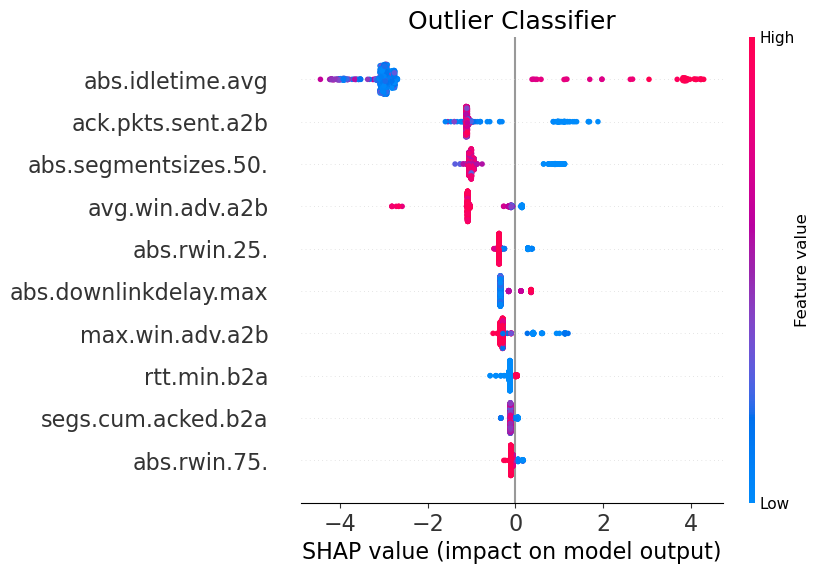

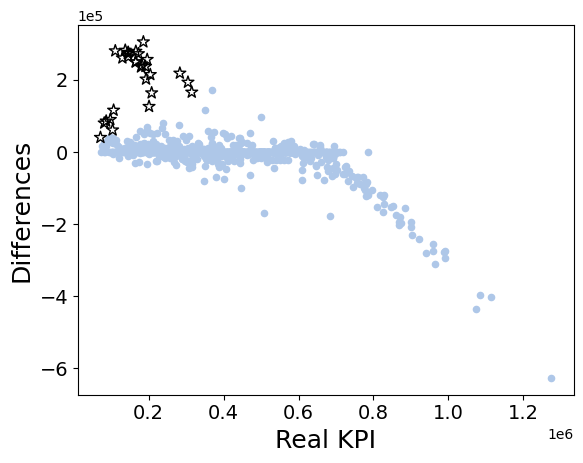

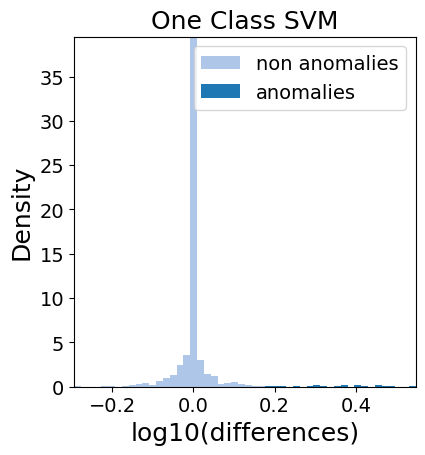

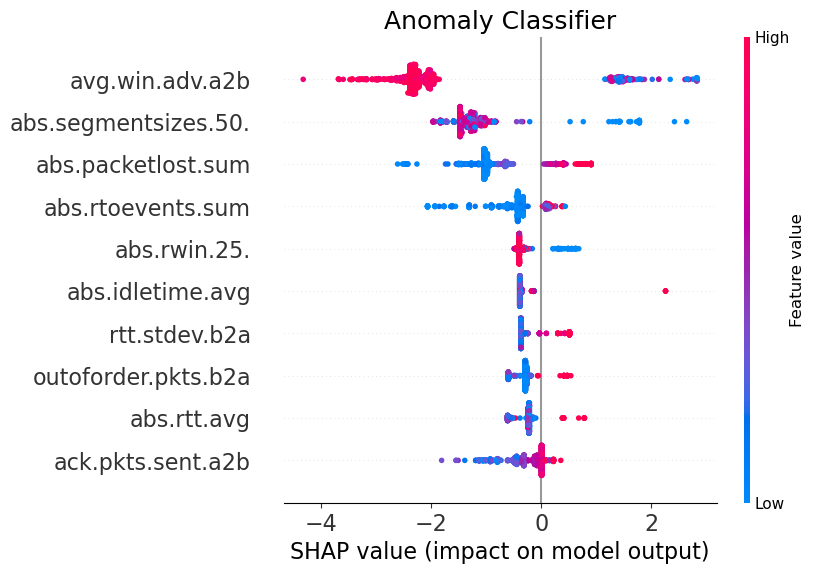

In [60]:
explainer_normality_model = shap.TreeExplainer(outlier_classifier)
shap_values1 = explainer_normality_model.shap_values(X_outlier_classifier)
shap.summary_plot(shap_values1, X_outlier_classifier, max_display=10, show=False)
fig, ax = plt.gcf(), plt.gca()
ax.xaxis.get_label().set_fontsize(16)
ax.yaxis.get_label().set_fontsize(16)
ax.ticklabel_format(axis='x', style='sci')
plt.tick_params(axis='both', labelsize=16)
plt.title('Outlier Classifier', fontsize=18)
plt.show()


fig = plt.figure(dpi=100)
plt.scatter(kpi_aux_anm[anomalies==False], y_difference_anm[anomalies==False], color=sns.color_palette("tab20")[1], s=20, label='Normality')
plt.scatter(kpi_aux_anm[anomalies==True], y_difference_anm[anomalies==True], color='k', marker='*', facecolors='none', s=80, label='Anomalies')
plt.xlabel('Real KPI', fontsize=18)
plt.ylabel('Differences', fontsize=18)
plt.tick_params(axis='both', labelsize=14)
plt.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
plt.show()

fig = plt.figure(figsize=(15,10), dpi=100)
anomaly_classes = np.unique(anomalies)
ax = fig.add_subplot(2,3,5)
ax.hist([y_difference_log10_anm[anomalies == i].reshape(-1) for i in anomaly_classes], 
        bins=50, 
        density = True,
        color=[sns.color_palette("tab20")[1],sns.color_palette("tab20")[0]],
        stacked=True,
        label = ['non anomalies', 
                 'anomalies'])
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=14)
plt.xlabel('log10(differences)', fontsize=18)
plt.ylabel('Density', fontsize=18)
plt.title('One Class SVM', fontsize=18)
plt.autoscale(axis='both', tight=True)
plt.show()

fig = plt.figure(dpi=100)
explainer_normality_model = shap.TreeExplainer(anomaly_classifier)
shap_values1 = explainer_normality_model.shap_values(X_anomaly_classifier)
shap.summary_plot(shap_values1, X_anomaly_classifier, max_display=10, show=False)
fig, ax = plt.gcf(), plt.gca()
ax.xaxis.get_label().set_fontsize(16)
ax.yaxis.get_label().set_fontsize(16)
ax.ticklabel_format(axis='x', style='sci')
plt.tick_params(axis='both', labelsize=16)
plt.title('Anomaly Classifier', fontsize=18)
plt.show()